# Создание маски кожных покровов лица на основе ключевых точек 

В данном файле представлен код с пояснениями. Можно посмотреть, как я шла к решению. Если важно только само решение, посмотрите web.py, там оформлено лучше и можно запустить со Streamlit на локальном хосте. 

Задачу решала таким образом:

1. Найти landmarks (с помощью shape_predictor_68_face_landmarks, скачивала с https://dlib.net/files/)

2. Наложить маску на всё лицо. Так как predictor_68_точек не видит верхнюю часть лба, координаты рассчитывала примерно, из предположения "над бровями 1/3 всего лица". Как вариант, можно использовать MediaPipe Face Mesh, который ищет большее количество точек. 

3. Вырезать из маски глаза, рот и брови.

In [33]:
import dlib
import cv2
import matplotlib.pyplot as plt
import numpy as np

Ниже - переработанный файл с dlib (ссылка: https://dlib.net/face_landmark_detection.py.html), который позволяет определелить landmarks и квадрат лица, а затем отрисовать их. 

Оставила win.add_overlay, т.к. интересно, что с ним отрисовывается не точками, а сразу линиями.

Image dimensions: 442x528
Number of faces detected: 1
Detection 0: Left: 142 Top: 192 Right: 365 Bottom: 415
Part 0: (137, 252), Part 1: (139, 286) ...


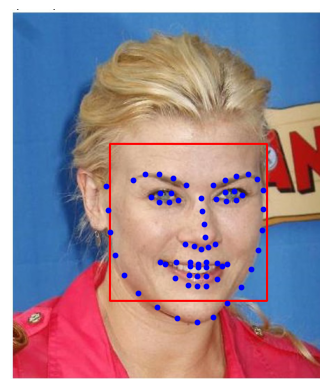

In [34]:
predictor_path = "shape_predictor_68_face_landmarks.dat"
img = dlib.load_rgb_image("face1.jpg")
img_copy = img.copy()

image_width, image_height = img.shape[1], img.shape[0]
print(f"Image dimensions: {image_width}x{image_height}")

detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor(predictor_path)
win = dlib.image_window()

win.clear_overlay()
win.set_image(img)

# Ask the detector to find the bounding boxes of each face. The 1 in the
# second argument indicates that we should upsample the image 1 time. This
# will make everything bigger and allow us to detect more faces.
dets = detector(img, 1)
print("Number of faces detected: {}".format(len(dets)))
for k, d in enumerate(dets):
    print("Detection {}: Left: {} Top: {} Right: {} Bottom: {}".format(
        k, d.left(), d.top(), d.right(), d.bottom()))
    # Get the landmarks/parts for the face in box d.
    shape = predictor(img, d)
    print("Part 0: {}, Part 1: {} ...".format(shape.part(0),
                                                shape.part(1)))
    # Draw the face landmarks on the screen.
    win.add_overlay(shape)
    for i in range(68):
        x = shape.part(i).x
        y = shape.part(i).y
    
        plt.scatter(x, y, c='b', s=10)
    
    for i, face in enumerate(dets):
        x, y, w, h = (face.left(), face.top(), face.width(), face.height())
        cv2.rectangle(img_copy, (x, y), (x + w, y + h), (255, 0, 0), 2)

win.add_overlay(dets)

plt.imshow(img_copy)
plt.axis("off")
plt.show()

По поводу количества определённых лиц - из задания понятно, что на вход подаётся изображение с одним лицом, так что не делала вариант для нескольких. Если на фото несколько лиц, то маска будет строиться только для одного.

Ниже - код, который в app.py находится в функции fill_face(). Он просто заполняет всё лицо маской, и опять же, верхняя часть определяется просто как треть того, что было ниже. Здесь нужно не ошибиться с нумерацией точек.

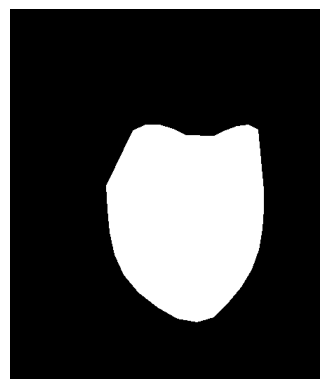

In [36]:
for k, d in enumerate(dets):
    shape = predictor(img, d)

    points = []

    # нижняя часть лица
    for i in range(17):

        x = shape.part(i).x
        y = shape.part(i).y

        points.append((x, y))

    face_height = shape.part(8).y - shape.part(19).y

    # верхняя часть (лоб)
    for i in range(26, 16, -1):

        x = shape.part(i).x
        y = shape.part(i).y - int(face_height*1/3) 

        points.append((x, y))

    points = np.array(points, dtype=np.int32)

    # пустая маска
    mask = np.zeros(img.shape[:2], dtype=np.uint8)

    cv2.fillPoly(mask, [points], 255)

plt.imshow(mask, cmap='gray')
plt.axis("off")
plt.show()

Ниже из получившейся маски вырезаются глаза, рот и брови. У рта берутся внешние границы - если брать все точки рта, то при фотографии с открытым ртом / зубами они тоже захватываются.

In [40]:
# левый глаз
left_eye = []

for i in range(36, 42):

    x = shape.part(i).x
    y = shape.part(i).y

    left_eye.append((x, y))

left_eye = np.array(left_eye, dtype=np.int32)

cv2.fillPoly(mask, [left_eye], 0)


# правый глаз
right_eye = []

for i in range(42, 48):

    x = shape.part(i).x
    y = shape.part(i).y

    right_eye.append((x, y))

right_eye = np.array(right_eye, dtype=np.int32)

cv2.fillPoly(mask, [right_eye], 0)


# рот
mouth = []

for i in range(48, 60):  # только наружняя часть рта

    x = shape.part(i).x
    y = shape.part(i).y

    mouth.append((x, y))

mouth = np.array(mouth, dtype=np.int32)

cv2.fillPoly(mask, [mouth], 0)


# левая бровь
left_eyebrow = []

for i in range(17, 22):
    x = shape.part(i).x
    y = shape.part(i).y

    left_eyebrow.append((x, y))

left_eyebrow = np.array(left_eyebrow, dtype=np.int32)
left_eyebrow = cv2.convexHull(left_eyebrow)

cv2.fillPoly(mask, [left_eyebrow], 0)


# правая бровь
right_eyebrow = []

for i in range(22, 27):
    x = shape.part(i).x
    y = shape.part(i).y

    right_eyebrow.append((x, y))

right_eyebrow = np.array(right_eyebrow, dtype=np.int32)
right_eyebrow = cv2.convexHull(right_eyebrow)

cv2.fillPoly(mask, [right_eyebrow], 0)

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(528, 442), dtype=uint8)

In [41]:
result = cv2.bitwise_and(img, img, mask=mask)

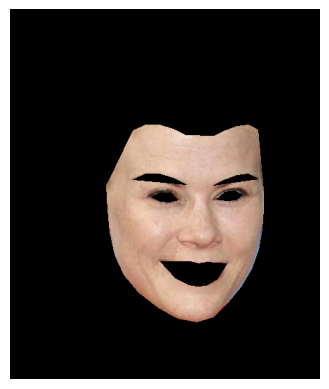

In [42]:
plt.imshow(result, cmap='gray')
plt.axis("off")
plt.show()

В итоге получаем маску с кожным покровом. Варианты для улучшения:
- использовать предиктор с большим количеством точек 
- добавить усреднение по цвету из выделенного, чтобы потом по цвету ещё лоб дораспознать. Если у человека например есть борода, то она тоже будет захвачена как кожный покров лица, возможно, доп. распознавание по цвету это решит

Также есть версия для Streamlit web.py, там функции отдельно оформлены, советую её посмотреть. 

Для запуска: "streamlit run .\web.py" (запустится на localhost).

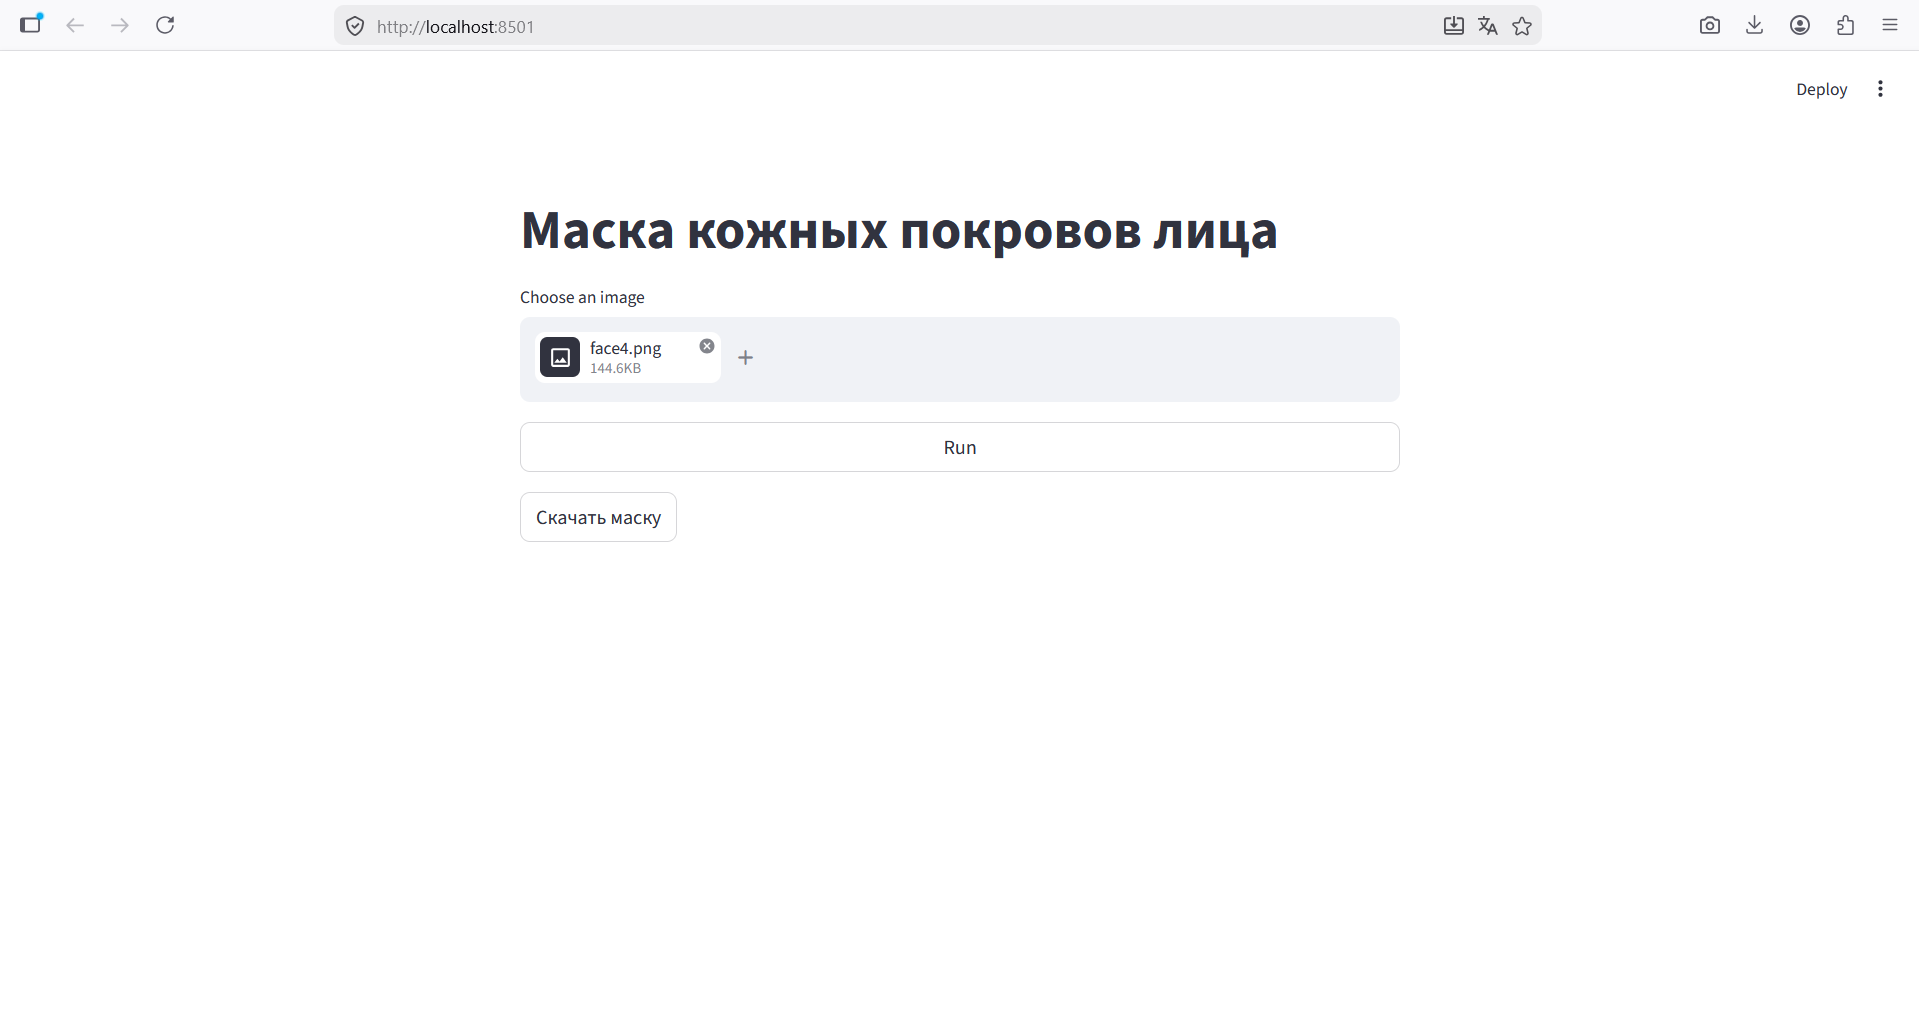